# Phase 3 — Modeling
## Credit Risk Scoring Model

We now train and evaluate two models on the processed data.

**Why two models?**
- **Logistic Regression** — simple, fast, interpretable. Coefficients directly tell you which features push toward default. Great baseline.
- **Random Forest** — ensemble of decision trees, captures non-linear patterns. Usually outperforms LR on tabular data.

Comparing both lets us understand the trade-off between interpretability and performance.

**What we measure:**
- ROC-AUC — overall ranking ability of the model
- Precision, Recall, F1 — per-class performance (especially for the Bad class)
- Confusion Matrix — exact breakdown of correct/incorrect predictions
- Cost-sensitive threshold tuning — using the 5:1 cost matrix from the dataset

## Step 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("Imports successful.")

Imports successful.


## Step 2 — Load Processed Data

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}   |  y_test : {y_test.shape}")
print(f"\nTrain class balance: {y_train.value_counts().to_dict()}")
print(f"Test  class balance: {y_test.value_counts().to_dict()}")

X_train: (1120, 41)  |  y_train: (1120,)
X_test : (200, 41)   |  y_test : (200,)

Train class balance: {1: 560, 0: 560}
Test  class balance: {0: 140, 1: 60}


## Step 3 — Train Logistic Regression

**What is Logistic Regression?**  
Despite the name, it's a classification algorithm. It models the probability that an applicant defaults:

```
P(default) = 1 / (1 + e^-(w1*x1 + w2*x2 + ... + wn*xn))
```

Each feature gets a **weight (coefficient)**. A positive weight means the feature increases default probability. A negative weight reduces it. This makes Logistic Regression highly interpretable.

**Key hyperparameters:**
- `C=1.0` — regularization strength (controls overfitting). Lower C = stronger regularization = simpler model.
- `max_iter=1000` — convergence iterations. We increase from default 100 because our feature space is large.
- `class_weight='balanced'` — tells the model to penalize misclassifying Bad Credit more. An alternative to SMOTE.

In [ ]:
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Cross-validation ROC-AUC on training set (5-fold)
lr_cv_auc = cross_val_score(lr, X_train, y_train, cv=5, scoring='roc_auc').mean()

print(f"Logistic Regression trained.")
print(f"Cross-val ROC-AUC (train): {lr_cv_auc:.4f}")

Logistic Regression trained.
Cross-val ROC-AUC (train): 0.8131


## Step 4 — Train Random Forest

**What is Random Forest?**  
An ensemble of many decision trees. Each tree is trained on a random subset of rows and features. The final prediction is a majority vote across all trees.

**Why is it usually better than a single tree?**  
A single decision tree overfits — it memorizes the training data. Random Forest corrects this through two sources of randomness:
1. **Bagging** — each tree sees a different bootstrap sample of training rows
2. **Feature randomness** — each split only considers a random subset of features

This makes individual trees weak but different from each other. Their errors cancel out when averaged.

**Key hyperparameters:**
- `n_estimators=300` — number of trees. More trees = more stable predictions (diminishing returns after ~200)
- `max_depth=None` — trees grow fully (no pruning). With bagging, this is fine.
- `min_samples_leaf=2` — each leaf needs at least 2 samples. Prevents very specific leaves that only exist in training data.

In [4]:
rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1   # Use all CPU cores
)
rf.fit(X_train, y_train)

rf_cv_auc = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc').mean()

print(f"Random Forest trained.")
print(f"Cross-val ROC-AUC (train): {rf_cv_auc:.4f}")

Random Forest trained.
Cross-val ROC-AUC (train): 0.9215


## Step 5 — ROC Curve Comparison

**What is ROC-AUC?**
- **ROC** = Receiver Operating Characteristic curve
- Plots **True Positive Rate** (recall for Bad class) vs **False Positive Rate** at every possible decision threshold
- **AUC** = Area Under the Curve. Range: 0.5 (random guessing) to 1.0 (perfect)

**Why ROC-AUC and not just accuracy?**
- With 70/30 imbalance, a model predicting "Good" every time gets 70% accuracy but AUC = 0.5
- ROC-AUC measures how well the model *ranks* bad borrowers above good ones — regardless of threshold
- It's threshold-independent, so it's a fair comparison between two models

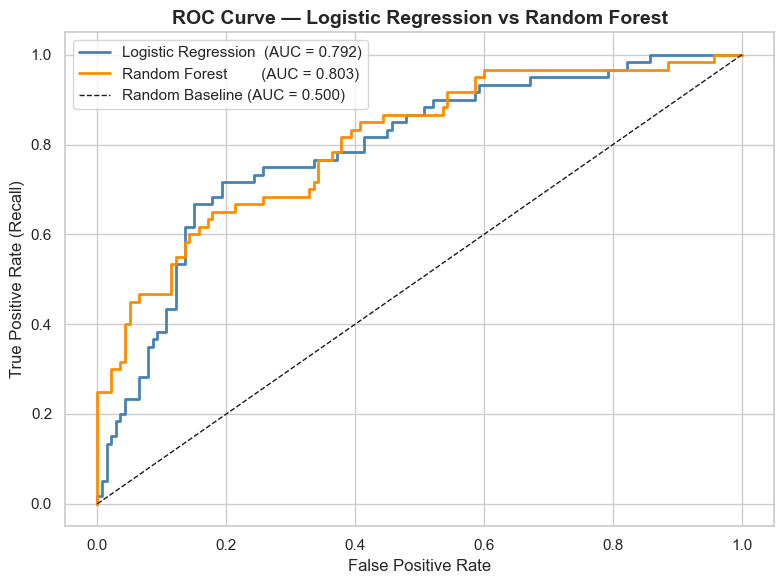

Logistic Regression AUC : 0.7919
Random Forest AUC       : 0.8035


In [5]:
lr_probs = lr.predict_proba(X_test)[:, 1]
rf_probs = rf.predict_proba(X_test)[:, 1]

lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression  (AUC = {lr_auc:.3f})', color='steelblue', lw=2)
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest        (AUC = {rf_auc:.3f})', color='darkorange', lw=2)
plt.plot([0,1], [0,1], 'k--', lw=1, label='Random Baseline (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve — Logistic Regression vs Random Forest', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../data/processed/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Logistic Regression AUC : {lr_auc:.4f}")
print(f"Random Forest AUC       : {rf_auc:.4f}")

## Step 6 — Precision-Recall Curve

**Why Precision-Recall in addition to ROC?**

ROC-AUC can be optimistic with imbalanced classes because it includes True Negatives (Good Credit correctly identified) — and there are a lot of those.

Precision-Recall focuses only on the minority class (Bad Credit):
- **Precision** — of all applicants we flagged as risky, how many actually were?
- **Recall** — of all actually risky applicants, how many did we catch?

There's always a trade-off:
- High Recall → catch more bad borrowers but also flag more good ones (lost revenue)
- High Precision → very confident when flagging but miss more bad borrowers (losses)

**The cost matrix tells us:** recall matters more here. Missing a bad borrower (false negative) costs 5x more.

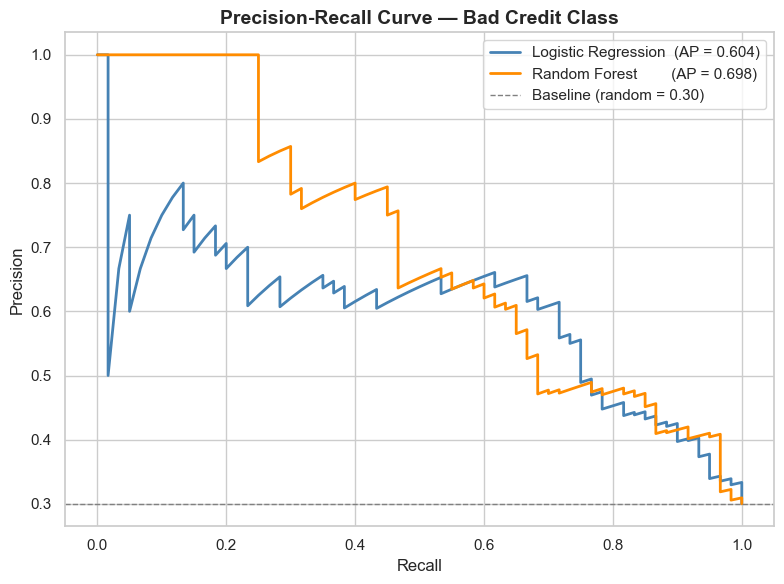

In [6]:
lr_prec, lr_rec, _ = precision_recall_curve(y_test, lr_probs)
rf_prec, rf_rec, _ = precision_recall_curve(y_test, rf_probs)

lr_ap = average_precision_score(y_test, lr_probs)
rf_ap = average_precision_score(y_test, rf_probs)

plt.figure(figsize=(8, 6))
plt.plot(lr_rec, lr_prec, label=f'Logistic Regression  (AP = {lr_ap:.3f})', color='steelblue', lw=2)
plt.plot(rf_rec, rf_prec, label=f'Random Forest        (AP = {rf_ap:.3f})', color='darkorange', lw=2)
plt.axhline(y=0.3, color='gray', linestyle='--', lw=1, label='Baseline (random = 0.30)')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve — Bad Credit Class', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../data/processed/precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Confusion Matrices at Default Threshold (0.5)

A confusion matrix shows the 4 possible outcomes for each prediction:

```
                  Predicted Good    Predicted Bad
Actual Good  →   True Negative      False Positive  (wrongly rejected — lost revenue)
Actual Bad   →   False Negative     True Positive   (missed default — financial loss × 5)
```

At the default threshold of 0.5, we predict Bad if `P(default) >= 0.5`.  
We'll then tune this threshold using the cost matrix.

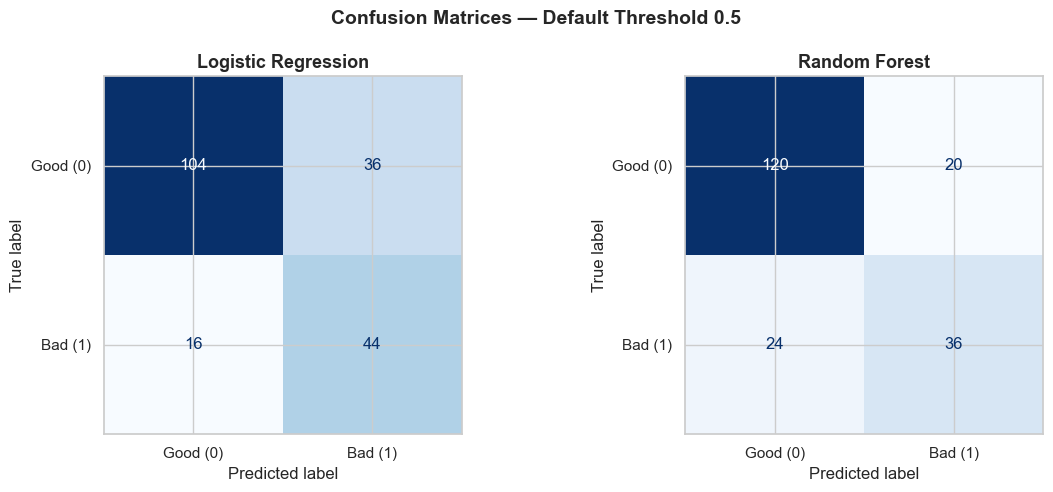

=== Logistic Regression ===
              precision    recall  f1-score   support

    Good (0)       0.87      0.74      0.80       140
     Bad (1)       0.55      0.73      0.63        60

    accuracy                           0.74       200
   macro avg       0.71      0.74      0.71       200
weighted avg       0.77      0.74      0.75       200

=== Random Forest ===
              precision    recall  f1-score   support

    Good (0)       0.83      0.86      0.85       140
     Bad (1)       0.64      0.60      0.62        60

    accuracy                           0.78       200
   macro avg       0.74      0.73      0.73       200
weighted avg       0.78      0.78      0.78       200



In [7]:
lr_preds = lr.predict(X_test)
rf_preds = rf.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(axes,
    [lr_preds, rf_preds],
    ['Logistic Regression', 'Random Forest']):

    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Good (0)', 'Bad (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — Default Threshold 0.5', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds, target_names=['Good (0)', 'Bad (1)']))
print("=== Random Forest ===")
print(classification_report(y_test, rf_preds, target_names=['Good (0)', 'Bad (1)']))

## Step 8 — Cost-Sensitive Threshold Tuning

**The problem with 0.5:**  
The default threshold treats all errors equally. But the dataset's cost matrix says:
- Missing a bad borrower (False Negative) costs **5**
- Wrongly rejecting a good borrower (False Positive) costs **1**

So we should lower the threshold to flag more applicants as risky (catches more bad borrowers, at the cost of some false alarms).

**How we find the optimal threshold:**  
For every possible threshold (0.01 → 0.99), we compute:
```
Total Cost = (5 × False Negatives) + (1 × False Positives)
```
The threshold with the **lowest total cost** is the one to use in production.

Optimal threshold — Logistic Regression : 0.23
Optimal threshold — Random Forest       : 0.22


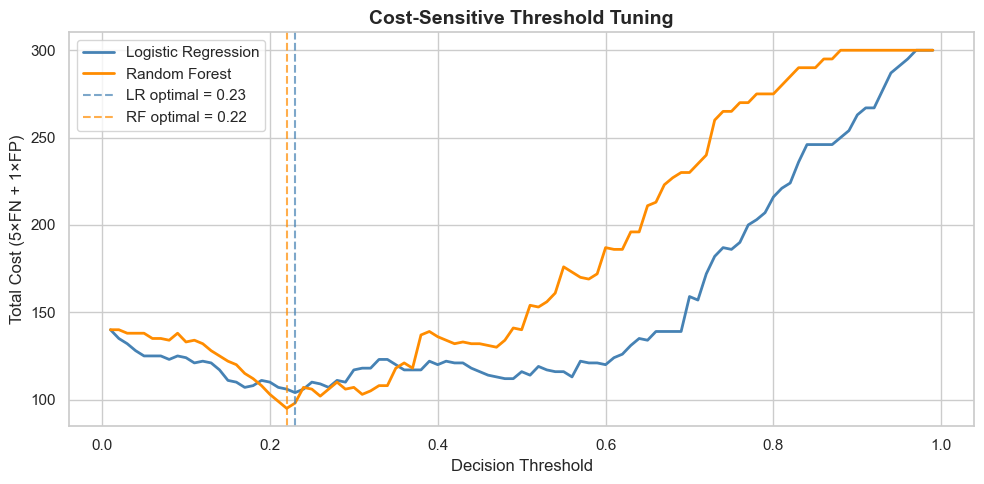

In [8]:
def find_optimal_threshold(probs, y_true, fn_cost=5, fp_cost=1):
    thresholds = np.arange(0.01, 1.0, 0.01)
    costs = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        cm = confusion_matrix(y_true, preds)
        tn, fp, fn, tp = cm.ravel()
        total_cost = fn_cost * fn + fp_cost * fp
        costs.append(total_cost)
    best_idx = np.argmin(costs)
    return thresholds[best_idx], costs

lr_best_thresh, lr_costs = find_optimal_threshold(lr_probs, y_test)
rf_best_thresh, rf_costs = find_optimal_threshold(rf_probs, y_test)

print(f"Optimal threshold — Logistic Regression : {lr_best_thresh:.2f}")
print(f"Optimal threshold — Random Forest       : {rf_best_thresh:.2f}")

thresholds = np.arange(0.01, 1.0, 0.01)
plt.figure(figsize=(10, 5))
plt.plot(thresholds, lr_costs, label='Logistic Regression', color='steelblue', lw=2)
plt.plot(thresholds, rf_costs, label='Random Forest',       color='darkorange', lw=2)
plt.axvline(lr_best_thresh, color='steelblue', linestyle='--', alpha=0.7, label=f'LR optimal = {lr_best_thresh:.2f}')
plt.axvline(rf_best_thresh, color='darkorange', linestyle='--', alpha=0.7, label=f'RF optimal = {rf_best_thresh:.2f}')
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Total Cost (5×FN + 1×FP)', fontsize=12)
plt.title('Cost-Sensitive Threshold Tuning', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../data/processed/threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9 — Final Evaluation at Optimal Threshold

Now we apply the cost-optimal threshold and compare results to the default 0.5.

In [9]:
def eval_at_threshold(name, probs, y_true, threshold):
    preds = (probs >= threshold).astype(int)
    cm = confusion_matrix(y_true, preds)
    tn, fp, fn, tp = cm.ravel()
    cost = 5 * fn + 1 * fp
    auc  = roc_auc_score(y_true, probs)
    print(f"\n{'='*50}")
    print(f"  {name}  |  Threshold = {threshold:.2f}")
    print(f"{'='*50}")
    print(f"  ROC-AUC        : {auc:.4f}")
    print(f"  True Positives : {tp}   (bad borrowers correctly flagged)")
    print(f"  False Negatives: {fn}   (bad borrowers missed — costly!)")
    print(f"  False Positives: {fp}   (good borrowers wrongly rejected)")
    print(f"  True Negatives : {tn}")
    print(f"  Total Cost     : {cost}  (5×{fn} + 1×{fp})")
    return preds

print("--- Default Threshold (0.5) ---")
eval_at_threshold("Logistic Regression", lr_probs, y_test, 0.5)
eval_at_threshold("Random Forest",       rf_probs, y_test, 0.5)

print("\n\n--- Optimal Threshold ---")
lr_final_preds = eval_at_threshold("Logistic Regression", lr_probs, y_test, lr_best_thresh)
rf_final_preds = eval_at_threshold("Random Forest",       rf_probs, y_test, rf_best_thresh)

--- Default Threshold (0.5) ---

  Logistic Regression  |  Threshold = 0.50
  ROC-AUC        : 0.7919
  True Positives : 44   (bad borrowers correctly flagged)
  False Negatives: 16   (bad borrowers missed — costly!)
  False Positives: 36   (good borrowers wrongly rejected)
  True Negatives : 104
  Total Cost     : 116  (5×16 + 1×36)

  Random Forest  |  Threshold = 0.50
  ROC-AUC        : 0.8035
  True Positives : 36   (bad borrowers correctly flagged)
  False Negatives: 24   (bad borrowers missed — costly!)
  False Positives: 20   (good borrowers wrongly rejected)
  True Negatives : 120
  Total Cost     : 140  (5×24 + 1×20)


--- Optimal Threshold ---

  Logistic Regression  |  Threshold = 0.23
  ROC-AUC        : 0.7919
  True Positives : 54   (bad borrowers correctly flagged)
  False Negatives: 6   (bad borrowers missed — costly!)
  False Positives: 74   (good borrowers wrongly rejected)
  True Negatives : 66
  Total Cost     : 104  (5×6 + 1×74)

  Random Forest  |  Threshold = 0.22

## Step 10 — Select Best Model & Save

We pick the model with the higher ROC-AUC as the primary model.  
We save both models + their thresholds so the Streamlit app can use them.

In [10]:
best_model_name = "Random Forest" if rf_auc >= lr_auc else "Logistic Regression"
best_model      = rf if rf_auc >= lr_auc else lr
best_threshold  = rf_best_thresh if rf_auc >= lr_auc else lr_best_thresh

print(f"Best model: {best_model_name}  (AUC = {max(rf_auc, lr_auc):.4f})")
print(f"Optimal threshold: {best_threshold:.2f}")

# Save all models and metadata
with open('../data/processed/lr_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('../data/processed/rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

model_meta = {
    'best_model': best_model_name,
    'lr_auc': lr_auc,
    'rf_auc': rf_auc,
    'lr_threshold': float(lr_best_thresh),
    'rf_threshold': float(rf_best_thresh),
    'best_threshold': float(best_threshold),
    'feature_names': list(X_train.columns)
}

import json
with open('../data/processed/model_meta.json', 'w') as f:
    json.dump(model_meta, f, indent=2)

print("\nSaved:")
print("  data/processed/lr_model.pkl")
print("  data/processed/rf_model.pkl")
print("  data/processed/model_meta.json")
print("\nPhase 3 — Modeling complete. Ready for Phase 4 — SHAP Explainability.")

Best model: Random Forest  (AUC = 0.8035)
Optimal threshold: 0.22

Saved:
  data/processed/lr_model.pkl
  data/processed/rf_model.pkl
  data/processed/model_meta.json

Phase 3 — Modeling complete. Ready for Phase 4 — SHAP Explainability.
